In [1]:
import pandas as pd

In [4]:
PEAK_PATH = "/home/stavz/masters/gdc/APM/data/TCGA_ATAC/TCGA-ATAC_PanCancer_PeakSet.txt"
peaks = pd.read_csv(PEAK_PATH, sep="\t")

In [5]:
peaks.rename(columns={"seqnames": "chrom"}, inplace=True)

,seqnames,start,end,name,score,annotation,percentGC
0,chr1,906012,906513,ACC_10,7.171193,Intron,0.612774
1,chr2,112541661,112542162,ACC_10008,22.030579,Promoter,0.554890
2,chr1,21673421,21673922,ACC_1001,6.459954,Distal,0.508982
3,chr2,112584205,112584706,ACC_10013,43.208555,Promoter,0.586826
4,chr2,112596243,112596744,ACC_10016,5.428209,Intron,0.491018
...,...,...,...,...,...,...,...
562704,chr21,32096356,32096857,UCEC_99917,3.602508,Intron,0.504990
562705,chr21,32339606,32340107,UCEC_99923,6.012783,Intron,0.479042
562706,chr21,32350221,32350722,UCEC_99925,7.122242,Intron,0.548902
562707,chr21,32572549,32573050,UCEC_99948,11.683105,Intron,0.542914


In [7]:
SV_PATH = "/home/stavz/masters/gdc/APM/data/SV_TCGA/SV_pipeline_out_test/07_final_sv_with_fimo/TCGA-A8-A09K-01A_strict_sv_set.csv"
sv = pd.read_csv(SV_PATH)

In [14]:
sv[sv["gene_hits"] != "[]"]["gene_hits"].iloc[0]

"[{'gene_name': 'CCL5', 'gene_id': 'ENSG00000271503.7', 'strand': '-', 'signed_dist': 0, 'overlap_start': 35871491, 'overlap_end': 35880793, 'overlap_bp': 9303, 'overlap_percent': 100.0, 'promoter_flag': 1, 'gene_body_flag': 1, 'exon_flag': 1, 'intron_only_flag': 0, 'upstream_5kb_flag': 0, 'downstream_5kb_flag': 0, 'region_hit': 'promoter,exon_or_UTR,', 'hit_side': 'span', 'stop_codon_flag': 1, 'start_codon_flag': 1, 'transcript_id': 'ENST00000605509.2', 'transcript_type': 'protein_coding'}, {'gene_name': 'STAT3', 'gene_id': 'ENSG00000168610.18', 'strand': '-', 'signed_dist': 0, 'overlap_start': 42313324, 'overlap_end': 42388568, 'overlap_bp': 75245, 'overlap_percent': 100.0, 'promoter_flag': 1, 'gene_body_flag': 1, 'exon_flag': 1, 'intron_only_flag': 0, 'upstream_5kb_flag': 0, 'downstream_5kb_flag': 0, 'region_hit': 'promoter,exon_or_UTR,', 'hit_side': 'span', 'stop_codon_flag': 1, 'start_codon_flag': 1, 'transcript_id': 'ENST00000590776.1', 'transcript_type': 'protein_coding_CDS_not_

In [15]:
ANNOT_PATH = "/home/stavz/masters/gdc/APM/test1/atac_peaks/atac_peaks_annotated.csv"
annot = pd.read_csv(ANNOT_PATH)

C:\Users\stavz\AppData\Local\Temp\ipykernel_18020\3571593371.py:2: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  annot = pd.read_csv(ANNOT_PATH)


In [26]:
annot["score"].describe()


count    562709.000000
mean          9.796561
std          16.996805
min           1.022347
25%           3.733862
50%           5.911621
75%          10.547721
max        2527.059401
Name: score, dtype: float64

<Axes: ylabel='Frequency'>

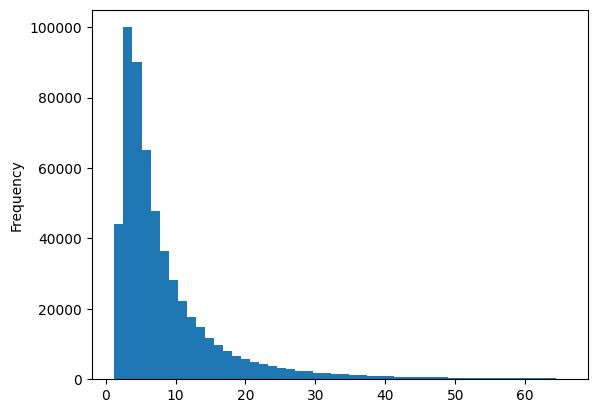

In [28]:
annot["score"].plot.hist(
    bins=50,
    range=(annot["score"].quantile(0.01), annot["score"].quantile(0.99))
)


In [36]:
annot.columns

Index(['peak_id', 'chrom', 'start', 'end', 'center', 'length', 'original_name',
       'score', 'annotation', 'percentGC', 'linked_genes', 'genes_by_tier',
       'n_genes_total', 'n_genes_overlapping', 'gene_links', 'n_ccres_total',
       'n_ccres_overlapping', 'ccre_types', 'ccre_links', 'TAD_domains',
       'TAD_boundary_overlaps'],
      dtype='object')

In [ ]:
annot[annot["n_genes_overlapping"] == 2]["gene_links"].iloc[0]

'{"TAP2": {"gene_id": "ENSG00000204267.20", "gene_type": "protein_coding", "dist_to_tss": 5023, "tier": "0\\u2013100kb", "tss_position": 32838784, "strand": "-", "body_overlap": {"overlaps": false, "overlap_bp": 0, "overlap_interval": null, "overlap_frac_of_peak": 0.0, "overlap_frac_of_gene": 0.0, "overlap_type": null}}, "PSMB8": {"gene_id": "ENSG00000204264.13", "gene_type": "protein_coding", "dist_to_tss": 371, "tier": "0\\u2013100kb", "tss_position": 32844679, "strand": "-", "body_overlap": {"overlaps": true, "overlap_bp": 501, "overlap_interval": [32843807, 32844308], "overlap_frac_of_peak": 1.0, "overlap_frac_of_gene": 0.126451, "overlap_type": "promoter"}}, "PSMB9": {"gene_id": "ENSG00000240065.10", "gene_type": "protein_coding", "dist_to_tss": 0, "tier": "0\\u2013100kb", "tss_position": 32844136, "strand": "+", "body_overlap": {"overlaps": true, "overlap_bp": 172, "overlap_interval": [32844136, 32844308], "overlap_frac_of_peak": 0.343313, "overlap_frac_of_gene": 0.010363, "overl

In [57]:
import ast
annot["TAD_boundary_overlaps"]






0         {"Kim_T47D": {"overlaps_boundary": false, "n_b...
1         {"Kim_T47D": {"overlaps_boundary": false, "n_b...
2         {"Kim_T47D": {"overlaps_boundary": false, "n_b...
3         {"Kim_T47D": {"overlaps_boundary": false, "n_b...
4         {"Kim_T47D": {"overlaps_boundary": false, "n_b...
                                ...                        
562704    {"Kim_T47D": {"overlaps_boundary": false, "n_b...
562705    {"Kim_T47D": {"overlaps_boundary": false, "n_b...
562706    {"Kim_T47D": {"overlaps_boundary": false, "n_b...
562707    {"Kim_T47D": {"overlaps_boundary": false, "n_b...
562708    {"Kim_T47D": {"overlaps_boundary": false, "n_b...
Name: TAD_boundary_overlaps, Length: 562709, dtype: object